# Retrieving English and French review data

## Objectives of this notebook

In this notebook, we will explore the Kaggle dataset of 100 million Steam reviews.

https://www.kaggle.com/datasets/kieranpoc/steam-reviews/data

- Data consistency and relevance
- Column containing the sentiment classification (binary)
- Already refined files available

### Reducing the volume by undersampling for fine-tuning

For our fine-tuning project we don't need that many reviews.
We also want to focus on two languages (English and French)

- Undersample this considerable volume for the two target languages
- Understand the **weighted_vote_score** and apply a first filter
- Filter authentic reviews (minimize bots) using additional metadata columns
- Filter by size due to tokenizer constraints

### Checking the format of reviews

- HTML / ASCII art
- Manual check of the sentiment class from the text

**Verify that the number of reviews remaining after filters and sentiment class balancing is sufficient**

## Library imports

In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import re

import kagglehub

## Helper methods

In [2]:
def column_summary(df: pd.DataFrame):
    summary = []
    for col in df.columns:
        col_type = df[col].dtype
        non_null = df[col].notna().sum()
        null_count = df[col].isna().sum()
        
        # Handle the case where the column contains lists (unhashable)
        try:
            unique_count = df[col].nunique()
        except TypeError:
            # If error (lists), temporarily convert to string
            unique_count = df[col].astype(str).nunique()
            print(f"⚠️ Column '{col}' contains non-hashable types (probably lists)")

        summary.append({
            'Column': col,
            'Type': str(col_type),
            'Non-Null Count': non_null,
            'Null Count': null_count,
            'Unique Values': unique_count,
        })

    # Display column summary
    print("=" * 80)
    print("Detailed column summary:")
    print("=" * 80)
    column_summary_df = pd.DataFrame(summary)
    print(column_summary_df.to_string(index=False))
    print("\n")

#### Balancing the sentiment column and displaying proportions

In [3]:
def print_voted_up_count_proportion(df:pd.DataFrame):
    voted_up_counts = df['voted_up'].value_counts()
    total_reviews = len(df)
    
    print("voted_up (reviews positive:1 / negative:0)")
    for voted_up_value, count in voted_up_counts.items():
        proportion = (count / total_reviews) * 100    
        print(f"voted_up = {voted_up_value}: Count = {count}, Proportion = {proportion:.2f}%")

    print(f"\nTo obtain a balanced 50/50 distribution by undersampling the majority class\n")
    print(f"We would have {min(voted_up_counts)} reviews per class. A total of {2 * min(voted_up_counts)} reviews.")

## Downloading the dataset from Kaggle Hub

### Kaggle and caching

In [4]:
# Download latest version
path = kagglehub.dataset_download("kieranpoc/steam-reviews")

print("Path to dataset files:", path)

def list_files_recursively(directory):
    for root, dirs, files in os.walk(directory):
        for file in files:
            print(os.path.join(root, file))

Path to dataset files: /home/sebas/.cache/kagglehub/datasets/kieranpoc/steam-reviews/versions/2


We retrieved two files:

- `/.cache/kagglehub/datasets/kieranpoc/steam-reviews/versions/2/all_reviews/all_reviews.csv`
    - a file containing 100 million video game reviews posted on the Steam marketplace, multi-language (40GB)

- `/.cache/kagglehub/datasets/kieranpoc/steam-reviews/versions/2/weighted_score_above_08.csv`
    - a lighter second file extracted from the first, with 500k Steam reviews having a high credibility/legitimate player score (weighted_vote_score > 0.8)

## Analysis of the full review file (40GB)

### Loading the file

In [5]:
sample = pd.read_csv(
    os.path.join(path, "all_reviews", "all_reviews.csv"),
    nrows=5
)

column_summary(sample)

Detailed column summary:
                        Column    Type  Non-Null Count  Null Count  Unique Values
              recommendationid   int64               5           0              5
                         appid   int64               5           0              1
                          game  object               5           0              1
                author_steamid   int64               5           0              5
        author_num_games_owned   int64               5           0              3
            author_num_reviews   int64               5           0              5
       author_playtime_forever   int64               5           0              4
author_playtime_last_two_weeks   int64               5           0              5
     author_playtime_at_review   int64               5           0              4
            author_last_played   int64               5           0              5
                      language  object               5           0       

To work with this large file, we will create two smaller ones using chunk processing.
- The first containing all French reviews (weighted_vote_score >= 0) with non-empty reviews.
- The second containing English reviews (weighted_vote_score >= 0.6) with non-empty reviews.

## Analysis of the file with review score 0.8

### Explanation of **weighted_vote_score > 0.8**

Valve has implemented a weighting system to prevent coordinated campaigns (bots or groups) 
from manipulating the featured reviews.

- It is not a sentiment indicator (positive/negative)
- It is a credibility/usefulness score for the review
- Bot reviews are often generic, with few votes, hence a low score
- Validated by real users

### Loading the file

In [6]:
df_reviews = pd.read_csv(
    f"{path}/weighted_score_above_08.csv",
    low_memory=True  # Optimize memory usage
)

df_reviews.head()

/tmp/ipykernel_2973/299715221.py:1: DtypeWarning: Columns (23) have mixed types. Specify dtype option on import or set low_memory=False.
  df_reviews = pd.read_csv(


,recommendationid,appid,game,author_steamid,author_num_games_owned,author_num_reviews,author_playtime_forever,author_playtime_last_two_weeks,author_playtime_at_review,author_last_played,...,voted_up,votes_up,votes_funny,weighted_vote_score,comment_count,steam_purchase,received_for_free,written_during_early_access,hidden_in_steam_china,steam_china_location
0,147449116,10,Counter-Strike,76561199183984450,51,12,2548,0,2480,1696305457,...,1,99,2,0.889438,0,1,0,0,1,NaN
1,147374264,10,Counter-Strike,76561198099573060,226,13,2369,0,2361,1696096555,...,1,122,8,0.914834,0,1,0,0,1,NaN
2,147357703,10,Counter-Strike,76561199080026894,118,23,13501,212,12957,1697630734,...,1,599,20,0.968375,3,1,0,0,1,NaN
3,147345102,10,Counter-Strike,76561198068970227,28,1,10668,640,9906,1698261011,...,1,59,12,0.826206,0,0,0,0,1,NaN
4,147284743,10,Counter-Strike,76561199137893460,19,5,543,10,526,1697810991,...,1,128,24,0.853612,0,1,0,0,1,NaN


In [7]:
column_summary(df_reviews)

Detailed column summary:
                        Column    Type  Non-Null Count  Null Count  Unique Values
              recommendationid   int64          498094           0         496233
                         appid   int64          498094           0          27315
                          game  object          498061          33          27261
                author_steamid   int64          498094           0         379636
        author_num_games_owned   int64          498094           0           5387
            author_num_reviews   int64          498094           0            911
       author_playtime_forever   int64          498094           0          65213
author_playtime_last_two_weeks   int64          498094           0           5065
     author_playtime_at_review   int64          498094           0          46691
            author_last_played   int64          498094           0         464661
                      language  object          498094           0       

### Displaying available languages

In [8]:
df_reviews['language'].value_counts()

language
english       193174
schinese      160121
russian        50558
spanish        16080
brazilian      15092
turkish        13848
koreana        11901
japanese        7339
german          6759
tchinese        5458
french          5285
polish          4399
ukrainian       2715
latam           1378
italian         1346
thai            1007
czech            824
hungarian        419
portuguese       209
romanian          38
finnish           34
vietnamese        32
dutch             18
swedish           16
bulgarian         14
norwegian         13
danish             9
greek              8
Name: count, dtype: int64

Verifying that the number of reviews per country matches reality

### Proportion of positive / negative reviews (voted_up)

According to the Kaggle documentation, the sentiment value is found in the **voted_up** column (binary)

In [9]:
print_voted_up_count_proportion(df_reviews)

voted_up (reviews positive:1 / negative:0)
voted_up = 1: Count = 420592, Proportion = 84.44%
voted_up = 0: Count = 77502, Proportion = 15.56%

To obtain a balanced 50/50 distribution by undersampling the majority class

We would have 77502 reviews per class. A total of 155004 reviews.


We can note a strong majority of reviews classified with a positive sentiment.

Two points of caution:
- Issue with the sentiment classification method
- High proportion of marketing campaigns with fake positive reviews

### Analysis of English reviews (project target)

In [10]:
df_review_en = df_reviews[df_reviews["language"] == "english"]
df_review_en.head(5)

,recommendationid,appid,game,author_steamid,author_num_games_owned,author_num_reviews,author_playtime_forever,author_playtime_last_two_weeks,author_playtime_at_review,author_last_played,...,voted_up,votes_up,votes_funny,weighted_vote_score,comment_count,steam_purchase,received_for_free,written_during_early_access,hidden_in_steam_china,steam_china_location
5,147263134,10,Counter-Strike,76561199013220131,41,10,2510,0,221,1696768614,...,1,300,13,0.863652,0,1,0,0,1,NaN
9,146253831,10,Counter-Strike,76561198847956367,0,1,404175,1486,396410,1698293849,...,1,102,1,0.865922,0,1,0,0,1,NaN
17,145002893,10,Counter-Strike,76561198995972388,50,50,81,0,81,1692978815,...,1,208,31,0.935513,0,1,0,0,1,NaN
23,144308037,10,Counter-Strike,76561198893691388,11,5,89,10,78,1698145024,...,1,367,19,0.875650,11,1,0,0,1,NaN
27,142806143,10,Counter-Strike,76561198200827945,0,27,26583,1,26568,1697487613,...,1,90,2,0.877432,0,1,0,0,1,NaN


In [11]:
column_summary(df_review_en)

Detailed column summary:
                        Column    Type  Non-Null Count  Null Count  Unique Values
              recommendationid   int64          193174           0         192198
                         appid   int64          193174           0          21923
                          game  object          193162          12          21888
                author_steamid   int64          193174           0         152763
        author_num_games_owned   int64          193174           0           4081
            author_num_reviews   int64          193174           0            696
       author_playtime_forever   int64          193174           0          38002
author_playtime_last_two_weeks   int64          193174           0           3382
     author_playtime_at_review   int64          193174           0          28781
            author_last_played   int64          193174           0         176702
                      language  object          193174           0       

### Displaying positive / negative proportions for English reviews

In [12]:
print_voted_up_count_proportion(df_review_en)

voted_up (reviews positive:1 / negative:0)
voted_up = 1: Count = 155952, Proportion = 80.73%
voted_up = 0: Count = 37222, Proportion = 19.27%

To obtain a balanced 50/50 distribution by undersampling the majority class

We would have 37222 reviews per class. A total of 74444 reviews.


## Analysis of English review lengths

In [43]:
# Length of reviews in words
texts = df_review_en['review'].tolist()
text_lengths = [len(text.split()) for text in texts]

print(f"\nMinimum length: {np.min(text_lengths):.0f} words")
print(f"\nMaximum length: {np.max(text_lengths):.0f} words")
print(f"\nAverage length: {np.mean(text_lengths):.0f} words")


Minimum length: 0 words

Maximum length: 2662 words

Average length: 190 words


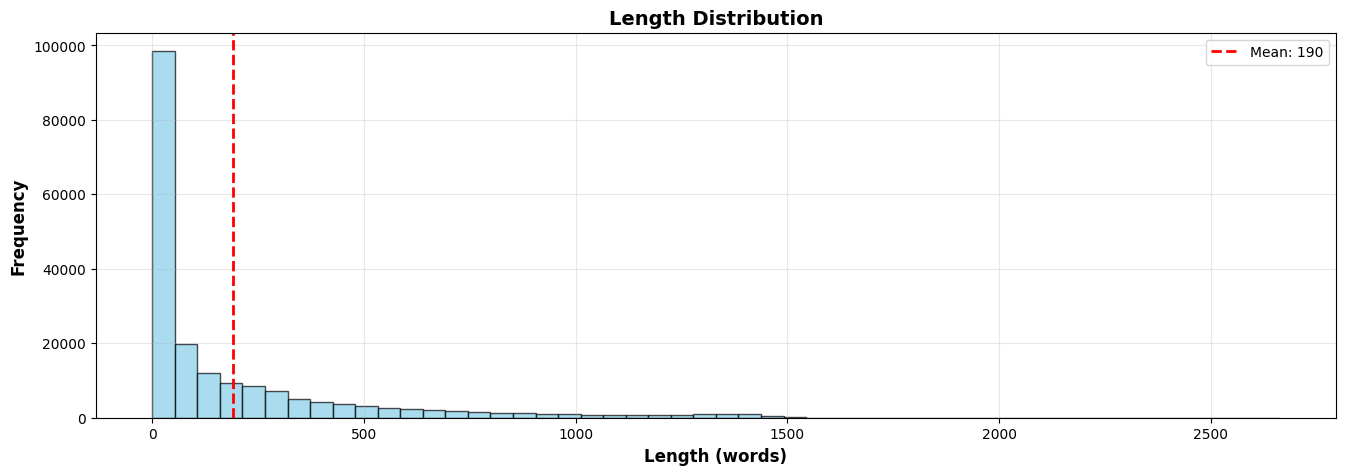

In [14]:
fig, (ax1) = plt.subplots(1, 1, figsize=(16, 5))

ax1: plt.Axes
# Length distribution
ax1.hist(text_lengths, bins=50, edgecolor='black', alpha=0.7, color='skyblue')
ax1.axvline(np.mean(text_lengths), color='red', linestyle='--', linewidth=2, 
            label=f'Mean: {np.mean(text_lengths):.0f}')
ax1.set_xlabel('Length (words)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax1.set_title('Length Distribution', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(alpha=0.3)

In [44]:
# Distribution
df_review_en_stats_dist = df_review_en.copy()
bins = [0, 10, 20, 50, 100, 300, 512, float('inf')]
labels = ['<10', '10-20', '20-50', '50-100', '100-300', '300-512', '>512']

df_review_en_stats_dist.loc[:, 'word_count'] = df_review_en_stats_dist['review'].str.split().str.len()

df_review_en_stats_dist['tranche'] = pd.cut(df_review_en_stats_dist['word_count'], bins=bins, labels=labels)

print('Distribution by length:')
print(df_review_en_stats_dist['tranche'].value_counts().sort_index())

Distribution by length:
tranche
<10        41874
10-20      26810
20-50      28258
50-100     19686
100-300    36630
300-512    17022
>512       22886
Name: count, dtype: int64


### Keras NLP Tokenizer

- Keras NLP will truncate texts that are too long.
- If texts are too short, training can be noisy.

#### Filter review sizes

Creating review size filtering parameters

In [16]:
TEXT_WORD_MIN_LENGTH = 10
TEXT_WORD_MAX_LENGTH = 400

#### Display proportion of reviews within target sizes

In [17]:
df_review_en_stats = df_review_en.copy()
df_review_en_stats.loc[:, 'word_count'] = df_review_en_stats['review'].str.split().str.len()

# Analyze ideal size
df_ideal_size_en = df_review_en_stats[(df_review_en_stats['word_count'] >= TEXT_WORD_MIN_LENGTH) & (df_review_en_stats['word_count'] <= TEXT_WORD_MAX_LENGTH)]
print(f"Total reviews: {len(df_review_en_stats)}")
print(f"Ideal size reviews: {len(df_ideal_size_en)}")
print(f"Percentage: {len(df_ideal_size_en)/len(df_review_en_stats)*100:.1f}%")

print_voted_up_count_proportion(df_ideal_size_en)

Total reviews: 193174
Ideal size reviews: 125293
Percentage: 64.9%
voted_up (reviews positive:1 / negative:0)
voted_up = 1: Count = 99600, Proportion = 79.49%
voted_up = 0: Count = 25693, Proportion = 20.51%

To obtain a balanced 50/50 distribution by undersampling the majority class

We would have 25693 reviews per class. A total of 51386 reviews.


#### # If strategy is to keep beginning + end

The strength of the sentiment signal is generally found at the beginning or end of a review.

In [18]:
# def truncate_middle(text, max_words=400):
#     words = text.split()
#     if len(words) <= max_words:
#         return text
#     half = max_words // 2
#     return ' '.join(words[:half] + words[-half:])

## Analysis of columns to maximize authentic reviews

We want to train our model on authentic, non-synthetic reviews.

**Maximize legitimate players**

The columns that will help us:
- weighted_vote_score
- author_playtime_forever
- steam_purchase
- received_for_free

Analysis on English reviews, Weighted_vote_score > 0.8, min and max length applied

### Weighted_vote_score

In [19]:
features_to_explore = [
    "weighted_vote_score",
]

stats = pd.DataFrame({
    'mean': df_ideal_size_en[features_to_explore].mean(),
    'min': df_ideal_size_en[features_to_explore].min(),
    'median': df_ideal_size_en[features_to_explore].median(),
    'max': df_ideal_size_en[features_to_explore].max(),
    'zeros_%': ((df_ideal_size_en[features_to_explore] == 0).sum() / len(df_ideal_size_en) * 100).round(1)
})

print(stats)

                        mean  min    median       max  zeros_%
weighted_vote_score  0.85825  0.8  0.850321  0.995547      0.0


#### Weighted vote score verification

The calculation method for **weighted_vote_score** is not publicly published by Steam.

To verify the logic of the metric anyway, let's check correlations with other columns

In [20]:
correlations = df_ideal_size_en.select_dtypes(include='number').corrwith(
    df_ideal_size_en['weighted_vote_score'],
    method='spearman'
).sort_values(ascending=False)

pd.DataFrame({
    'abs_correlation': correlations.abs()
}).sort_values('abs_correlation', ascending=False)

,abs_correlation
weighted_vote_score,1.000000
votes_up,0.620771
votes_funny,0.266326
comment_count,0.138549
author_last_played,0.067914
voted_up,0.064647
timestamp_updated,0.057619
recommendationid,0.055750
timestamp_created,0.055750
author_playtime_forever,0.050717


The score appears to be correctly calculated based on player activity.

We will continue to use this quality value to undersample the large dataset (40GB)

The following columns will be ignored (redundant)

- votes_up	0.625257
- votes_funny	0.266426
- comment_count	0.135675
- author_last_played	0.069433
- voted_up	0.062689

### Author_playtime_forever

Corresponds to the time spent playing the game before posting a review.
 - Filter basic bots that have not simulated any activity
 - Filter spam

In [21]:
features_to_explore = [
    "author_playtime_forever",
]

stats = pd.DataFrame({
    'mean': df_ideal_size_en[features_to_explore].mean(),
    'min': df_ideal_size_en[features_to_explore].min(),
    'median': df_ideal_size_en[features_to_explore].median(),
    'max': df_ideal_size_en[features_to_explore].max(),
    'zeros_%': ((df_ideal_size_en[features_to_explore] == 0).sum() / len(df_ideal_size_en) * 100).round(1)
})

print(stats)

                                 mean  min  median      max  zeros_%
author_playtime_forever  17981.309219    0  1149.0  5440698      8.7


### Steam_purchase

Verified purchase

In [22]:
for feat in ['steam_purchase']:
    counts = df_ideal_size_en[feat].value_counts()
    pcts = df_ideal_size_en[feat].value_counts(normalize=True) * 100
    
    print(f"\n{feat}:")
    print(f"  0: {counts.get(0, 0):,} ({pcts.get(0, 0):.1f}%)")
    print(f"  1: {counts.get(1, 0):,} ({pcts.get(1, 0):.1f}%)")


steam_purchase:
  0: 38,641 (30.8%)
  1: 86,652 (69.2%)


### Received_for_free

Received for free — biased sentiment?

In [23]:
for feat in ['steam_purchase']:
    counts = df_ideal_size_en[feat].value_counts()
    pcts = df_ideal_size_en[feat].value_counts(normalize=True) * 100
    
    print(f"\n{feat}:")
    print(f"  0: {counts.get(0, 0):,} ({pcts.get(0, 0):.1f}%)")
    print(f"  1: {counts.get(1, 0):,} ({pcts.get(1, 0):.1f}%)")


steam_purchase:
  0: 38,641 (30.8%)
  1: 86,652 (69.2%)


## Verifying that authentic reviews are sufficient in number

In [24]:
df_clean = df_reviews.copy()

#### Fine-tuning v1 will be performed on English reviews using the bert_en preset

In [25]:
df_clean = df_clean[df_clean["language"] == "english"]

#### Creating the word_count column

In [26]:
df_clean.loc[:, 'word_count'] = df_clean['review'].str.split().str.len()

#### Filter min and max size

In [27]:
df_clean = df_clean[df_clean['word_count'] >= TEXT_WORD_MIN_LENGTH]

#### Maximize authentic reviews

In [28]:
def clean_review_to_keep_legitimate(df:pd.DataFrame):
    df_clean = df[
        (df['steam_purchase'] == 1) &           # Verified purchase
        (df['received_for_free'] == 0) &        # Not received for free
        (df['author_playtime_forever'] > 30)    # At least 30 minutes played
    ]
    
    return df_clean

#### Checking the remaining count after sentiment class balancing

In [29]:
df_clean = clean_review_to_keep_legitimate(df_clean)

# Stats
print_voted_up_count_proportion(df_clean)

voted_up (reviews positive:1 / negative:0)
voted_up = 1: Count = 75981, Proportion = 81.24%
voted_up = 0: Count = 17540, Proportion = 18.76%

To obtain a balanced 50/50 distribution by undersampling the majority class

We would have 17540 reviews per class. A total of 35080 reviews.


By filtering reviews a bit more, we can still obtain a sufficient number for model training

## Manual check of review format and positive / negative sentiment class

In [30]:
df_check_voted_up = df_reviews.copy()

In [31]:
df_check_voted_up.loc[:, 'word_count'] = df_check_voted_up['review'].str.split().str.len() # Creating the word_count column

In [ ]:
# wee keep only english reviews
df_check_voted_up = df_check_voted_up[df_check_voted_up["language"] == "english"]

### ASCII Art detection

Some reviews contain no words at all but are ASCII art
https://fr.wikipedia.org/wiki/Art_ASCII


To avoid adding noise to training, I prefer to remove them at first.

In [33]:
def has_enough_letters(text: str, min_ratio=0.5):
    
    if not isinstance(text, str) or len(text) == 0:
        return False
    
    letters = sum(c.isalpha() for c in text)
    return (letters / len(text)) >= min_ratio

In [34]:
# View some examples of filtered reviews
removed = df_check_voted_up[~df_check_voted_up['review'].apply(has_enough_letters)]

print(f"Removed reviews: {len(removed)}")

for review in removed['review'].head(10):
    print(review[:100])
    print("---")

Removed reviews: 4421
cs 1.6>cs2
---
Here I will leave the cat, friends who pass by can pet it and give it a thumbs up 　　　 　　／＞　　フ 　　　 　　
---
best game in the solar system  ⣿⣿⣿⣿⣿⣿⣿⣿⡿⠿⠛⠛⠛⠋⠉⠈⠉⠉⠉⠉⠛⠻⢿⣿⣿⣿⣿⣿⣿⣿ ⣿⣿⣿⣿⣿⡿⠋⠁⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠉⠛⢿⣿⣿⣿⣿ ⣿⣿⣿⣿⡏⣀⠀
---
Here I will leave the cat, friends who pass by can pet it and give it a thumbs up 　　　 　　／＞　　フ 　　　 　　
---
Players who's still play this game: ⣿⣿⣿⣿⣿⣿⣿⣿⡿⠿⠛⠛⠛⠋⠉⠈⠉⠉⠉⠉⠛⠻⢿⣿⣿⣿⣿⣿⣿⣿ ⣿⣿⣿⣿⣿⡿⠋⠁⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠉⠛⢿⣿⣿⣿⣿ ⣿⣿
---
Yes, this is my favorite game. How could you tell?  ⣿⣿⣿⣿⣿⣿⣿⣿⡿⠿⠛⠛⠛⠋⠉⠈⠉⠉⠉⠉⠛⠻⢿⣿⣿⣿⣿⣿⣿⣿ ⣿⣿⣿⣿⣿⡿⠋⠁⠀⠀⠀⠀⠀⠀⠀⠀⠀
---
people who still play this game ⣿⣿⣿⣿⣿⣿⣿⣿⡿⠿⠛⠛⠛⠋⠉⠈⠉⠉⠉⠉⠛⠻⢿⣿⣿⣿⣿⣿⣿⣿ ⣿⣿⣿⣿⣿⡿⠋⠁⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠉⠛⢿⣿⣿⣿⣿ ⣿⣿⣿⣿⡏⣀
---
⣿⣿⣿⣿⣿⣿⣿⣿⡿⠿⠛⠛⠛⠋⠉⠈⠉⠉⠉⠉⠛⠻⢿⣿⣿⣿⣿⣿⣿⣿ ⣿⣿⣿⣿⣿⡿⠋⠁⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠉⠛⢿⣿⣿⣿⣿ ⣿⣿⣿⣿⡏⣀⠀⠀⠀⠀⠀⠀⠀⣀⣤⣤⣤⣄⡀⠀⠀⠀⠀⠀⠀⠀⠙⢿⣿⣿ ⣿⣿⣿⢏⣴⣿⣷
---
⣿⣿⣿⣿⣿⣿⣿⡿⠟⠛⠉⠉⠉⠉⠋⠉⠉⠙⠛⠛⠻⠿⢿⣿⣿⣿⣿⣿⣿⣿ ⣿⣿⣿⣿⠿⠋⠁⠄⠄⠄⠄⠄⠄⠄⠄⠄⠄⠄⠄⠄⠄⠄⠈⠉⠻⣿⣿⣿⣿⣿ ⣿⣿⡟⠁⠄⠄⠄⠄⠄⠄⠄⠄⠄⠄⠄⠄⠄⠄⠄⠄⠄⠄⠄⠄⠄⠙⢻⣿⣿⣿ ⣿⠏⠄⠄⠄⠄⠄
---
[h1] [b] ALL TIME BEST! [/b] [/h1]
---


In [35]:
# Remove them for the rest of the review analysis
df_clean = df_check_voted_up[df_check_voted_up['review'].apply(has_enough_letters)]

print(f"Before: {len(df_check_voted_up)}")
print(f"After: {len(df_clean)}")

df_check_voted_up = df_clean

Before: 193174
After: 188753


### Notes on emoji/emoticon handling

BERT already handles emojis/emoticons. Its tokenizer treats them as unknown tokens or decomposes them, but the surrounding context is generally sufficient.

We will filter by length to have a minimum of 10 words. The text around the emoji carries most of the positive or negative signal.

Note that BERT/KerasNLP handles this:

- The tokenizer treats them as unknown tokens [UNK] or decomposes them
- The surrounding context compensates

In [36]:
# For later testing, transform emojis into simple text

emoticons = {
    r':\)|:-\)|=\)': ' smile ',
    r':\(|:-\(|=\(': ' sad ',
    r":\'\(": ' cry ',
    r';\)|;-\)': ' wink ',
    r':D|:-D|=D': ' laugh ',
    r'XD': ' lol ',
    r':P|:-P|=P': ' tongue ',
}

def replace_emoticons(text):
    for pattern, replacement in emoticons.items():
        text = re.sub(pattern, replacement, text)
    return text

# On the same issue, we can also consider using libraries like 'emoji' for more complete emoji handling.
# For example:
# import emoji
# def replace_emojis(text):
#     return emoji.demojize(text, delimiters=(" ", " "))        

# Simple dictionary for a few common symbols
symbols = {
    '♥': ' love ',
    '★': ' star ',
    '☆': ' star ',
    '♫': ' music ',
    '✓': ' ok ',
    '✗': ' no ',
    '👍': ' good ',
    '👎': ' bad ',
}

def replace_symbols(text):
    for symbol, word in symbols.items():
        text = text.replace(symbol, word)
    return text

### Notes on HTML/BBCode handling

As seen during training, the keras NLP library I will use includes a preprocessing phase for sentences.

It can still be beneficial to remove HTML tags from reviews beforehand:
- The 512-token limit is reached faster
- If keras NLP keeps the tags, this can create noise / a less clear signal.

In [37]:
# For the rest of the review analysis we will remove them to get the closest view possible to the final data that will be used for training

In [38]:
def clean_tags(text: str):
    if not isinstance(text, str):
        return text
    text = re.sub(r'\[/?[a-zA-Z0-9]+[^\]]*\]', '', text)
    text = re.sub(r'</?[a-zA-Z0-9]+[^>]*>', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [39]:
df_check_voted_up['review'] = df_check_voted_up['review'].apply(clean_tags)

### Checking negative reviews

In [40]:
for i, review in enumerate(df_check_voted_up[(df_check_voted_up['voted_up'] == 0) & 
                                    (df_check_voted_up["language"] == "english") & 
                                    (df_check_voted_up['steam_purchase'] == 1)  & 
                                    (df_check_voted_up['received_for_free'] == 0) & 
                                    (df_check_voted_up['author_playtime_forever'] > 30) & 
                                    (df_check_voted_up['word_count'] <= 30) & # pas trop long pour relecture
                                    (df_check_voted_up['word_count'] > TEXT_WORD_MIN_LENGTH)]['review'].head(10), 1):
    print(f"--- Review {i} ---")
    print(review)
    print()

--- Review 1 ---
I flipped a coin to decide whether to give this a positive or negative review

--- Review 2 ---
I like this game a lot, however I wouldn't really recommend it to anyone either

--- Review 3 ---
Yeah, great idea to let me spend time on character creation and only then say that this feature is dlc feature

--- Review 4 ---
its pretty much just access to the Workshop and the story editor, which is pretty bare bones at the moment. Will be happy to revisit when more tools are added.

--- Review 5 ---
The servers are still online for those who played it before, but no new players can play online.

--- Review 6 ---
I really tried to like this, the other reviews stating the game starts at chapter 2 are right. What they don't tell you is that it doesn't get any better.

--- Review 7 ---
Generally, This game is good, but this game have a lot of bugs about saving and by this bug I lost my save.

--- Review 8 ---
If you are using Windows 10, do not buy this game. Because this game

The reviews are indeed negative.

Note: We see one review with no real words and another in English that is tagged as French

### Checking positive reviews

In [41]:
for i, review in enumerate(df_check_voted_up[(df_check_voted_up['voted_up'] == 1) & 
                                    (df_check_voted_up["language"] == "english") & 
                                    (df_check_voted_up['steam_purchase'] == 1)  & 
                                    (df_check_voted_up['received_for_free'] == 0) & 
                                    (df_check_voted_up['author_playtime_forever'] > 30) & 
                                    (df_check_voted_up['word_count'] <= 30) & # pas trop long pour relecture
                                    (df_check_voted_up['word_count'] > TEXT_WORD_MIN_LENGTH)]['review'].head(10), 1):
    print(f"--- Review {i} ---")
    print(review)
    print()

--- Review 1 ---
best played with a membrane keyboard, a rollerball mouse, and a 800x600 CRT

--- Review 2 ---
Counter-Strike won't ever be canceled. Counter-Strike won't be dismantled. Counter-Strike gonna be together. Counter-Strike gonna be FOREVER! Best shooter for 20 years. Steam evolved because of this game.

--- Review 3 ---
Nobody's gonna read this review, so I'll just say I'm gay

--- Review 4 ---
Real man`s counter-strike lmao This game is over two times older than most csgo players.

--- Review 5 ---
the wife said if she gets a lot of awards, she will buy a case of beer. HELP!

--- Review 6 ---
If she doesn't know this game, she is too young for you bro!

--- Review 7 ---
Man, I play this from primary school time till master degree

--- Review 8 ---
One of the best games of our childhood. I don't think that there will be any other iconic and greatest game like CS. ♥

--- Review 9 ---
This game is older than half of the steam community users, love it.

--- Review 10 ---
I was

The reviews are generally positive, even if some have a second-degree tone

### Applying the legitimate review filter and visualizing the remaining count

In [42]:
df_check_voted_up = clean_review_to_keep_legitimate(df_check_voted_up)

# filtre size min et max
df_check_voted_up = df_check_voted_up[
    (df_check_voted_up['word_count'] >= TEXT_WORD_MIN_LENGTH) &
    (df_check_voted_up['word_count'] <= TEXT_WORD_MAX_LENGTH)
]

# Stats
print_voted_up_count_proportion(df_check_voted_up)

voted_up (reviews positive:1 / negative:0)
voted_up = 1: Count = 60095, Proportion = 82.72%
voted_up = 0: Count = 12558, Proportion = 17.28%

To obtain a balanced 50/50 distribution by undersampling the majority class

We would have 12558 reviews per class. A total of 25116 reviews.


End of exploration of the first review file available on Kaggle. (weighted_score_vote > 0.8)

We can now move on to creating the two English and French datasets from the main file available on Kaggle (40GB)

## Conclusion

To work with this large file, we will create two smaller ones using chunk processing.
- The first containing all French reviews (weighted_vote_score >= 0) with non-empty reviews.
- The second containing English reviews (weighted_vote_score >= 0.6) with non-empty reviews.